# Demo 07: Discretized Sensitivity Kernels and the Forward Operator G

This notebook demonstrates how to build the **discretized forward operator** $G$ for a
1-D seismic travel-time inverse problem on a spherical mesh.

**Workflow**

1. Load a 1-D Earth model (PREM) and build a spherical shell mesh.
2. Create **synthetic seismic observations** for 2 events × 2 stations (P-waves only).
3. Compute the **discretized sensitivity kernels**

$$\tilde K_{ij} = -\frac{L_{ij}}{v_j^2}, \quad \text{units: s km}^{-1}$$

for each of the 4 source–receiver pairs.

4. Stack the kernels row-wise to form the **forward operator matrix**

$$G \in \mathbb{R}^{N_{\text{obs}} \times N_{\text{cells}}}$$

so that $G\, \delta\mathbf{m} = \delta\mathbf{d}$.

5. Generate fake data $\mathbf{d} = G\, \mathbf{m}_{\text{true}}$ from a known velocity perturbation.
6. Solve the **damped least-squares inverse problem**

$$\hat{\mathbf{m}} = (G^T G + \lambda I)^{-1} G^T \mathbf{d}$$

and examine model recovery as a function of the regularisation parameter $\lambda$.


## 1 · Imports and Setup

In [87]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import linalg

from sensray import PlanetModel

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

print("All imports OK")


All imports OK


## 2 · Load Planet Model and Build Spherical Mesh

We use PREM as the reference model.  A uniform radial spacing of **dr = 200 km** is used
throughout — coarse enough that the 4 ray paths give a well-conditioned (but still
under-determined) system.

In [88]:
# ── Load PREM ──────────────────────────────────────────────────────────────
model = PlanetModel.from_standard_model('M1')
print(f"Model  : {model.name}")
print(f"Radius : {model.radius:.1f} km")

# ── Build radial grid: uniform spacing dr = 200 km ─────────────────────────
DR = 20.0   # km
mesh_radii = list(np.arange(0.0, model.radius, DR))
if mesh_radii[-1] < model.radius:
    mesh_radii.append(float(model.radius))

print(f"\ndr = {DR} km  →  {len(mesh_radii)} boundaries, {len(mesh_radii)-1} shells")

# ── Generate spherical mesh and populate vp ────────────────────────────────
mesh = model.create_mesh('spherical', radii=mesh_radii)
mesh.populate_properties(['vp'])

N_CELLS = mesh.mesh.n_cells
shell_radii   = np.array(mesh.mesh.radii, dtype=float)        # ascending
shell_centres = 0.5 * (shell_radii[:-1] + shell_radii[1:])   # centre of each shell
shell_depths  = model.radius - shell_centres

vp_ref = np.array(mesh.mesh.cell_data['vp'], dtype=float)

print(f"\nMesh ready: {N_CELLS} shells")
print(f"vp range  : {vp_ref.min():.2f} – {vp_ref.max():.2f} km/s")


Model  : M1
Radius : 1737.1 km

dr = 20.0 km  →  88 boundaries, 87 shells
Generated spherical mesh: 87 layers, 88 boundaries
Populated properties: ['vp']

Mesh ready: 87 shells
vp range  : 4.56 – 8.24 km/s


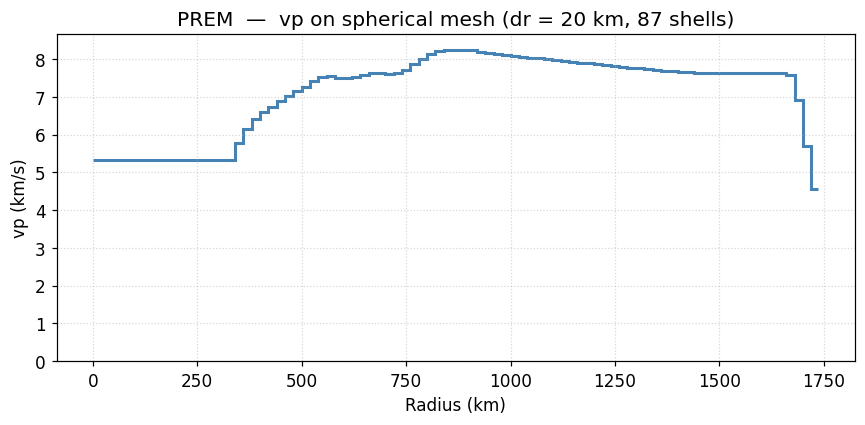

Shell centres (km): [10. 30. 50. 70. 90.] ...


In [89]:
# ── Quick look at the vp profile ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.stairs(vp_ref, shell_radii, baseline=None, color='steelblue', lw=2, label='vp (mesh)')
ax.set_xlabel('Radius (km)')
ax.set_ylabel('vp (km/s)')
ax.set_title(f'PREM  —  vp on spherical mesh (dr = {DR:.0f} km, {N_CELLS} shells)')
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()
print(f"Shell centres (km): {shell_centres[:5].round(1)} ...")


## 3 · Define 2 Events and 2 Stations

Both events are shallow (depth 10 km).  The stations are placed at different
epicentral distances to ensure the four ray paths sample different depth ranges
and give complementary sensitivity coverage.

In [90]:
# ── Source–receiver geometry ───────────────────────────────────────────────
events = {
    'E1': {'depth_km':   10.0},
    'E2': {'depth_km':  100.0},
    'E3': {'depth_km':  300.0},
    'E4': {'depth_km':  600.0},
    'E5': {'depth_km': 1000.0},
}

stations = {
    'S1': {'dist_deg':  20.0},   # very shallow turning point
    'S2': {'dist_deg':  45.0},   # upper mantle
    'S3': {'dist_deg':  90.0},   # mid-mantle
    'S4': {'dist_deg': 120.0},   # deep mantle
    'S5': {'dist_deg': 150.0},   # near-CMB
}

pairs = [(e, s) for e in events for s in stations]
print(f"Source–receiver pairs ({len(pairs)} total):")
for ev, st in pairs:
    print(f"  {ev}–{st}   depth={events[ev]['depth_km']:6.0f} km    Δ={stations[st]['dist_deg']}°")


Source–receiver pairs (25 total):
  E1–S1   depth=    10 km    Δ=20.0°
  E1–S2   depth=    10 km    Δ=45.0°
  E1–S3   depth=    10 km    Δ=90.0°
  E1–S4   depth=    10 km    Δ=120.0°
  E1–S5   depth=    10 km    Δ=150.0°
  E2–S1   depth=   100 km    Δ=20.0°
  E2–S2   depth=   100 km    Δ=45.0°
  E2–S3   depth=   100 km    Δ=90.0°
  E2–S4   depth=   100 km    Δ=120.0°
  E2–S5   depth=   100 km    Δ=150.0°
  E3–S1   depth=   300 km    Δ=20.0°
  E3–S2   depth=   300 km    Δ=45.0°
  E3–S3   depth=   300 km    Δ=90.0°
  E3–S4   depth=   300 km    Δ=120.0°
  E3–S5   depth=   300 km    Δ=150.0°
  E4–S1   depth=   600 km    Δ=20.0°
  E4–S2   depth=   600 km    Δ=45.0°
  E4–S3   depth=   600 km    Δ=90.0°
  E4–S4   depth=   600 km    Δ=120.0°
  E4–S5   depth=   600 km    Δ=150.0°
  E5–S1   depth=  1000 km    Δ=20.0°
  E5–S2   depth=  1000 km    Δ=45.0°
  E5–S3   depth=  1000 km    Δ=90.0°
  E5–S4   depth=  1000 km    Δ=120.0°
  E5–S5   depth=  1000 km    Δ=150.0°


## 4 · Compute P-wave Ray Paths with TauP

Use ObsPy's TauPy (wrapped by `model.taupy_model`) to compute realistic ray paths.
Only **P** arrivals are requested.

In [91]:
print("Building TauP model (first call may take ~10 s) …")
taup = model.taupy_model
print("TauP ready.\n")

# ── Compute P-wave arrivals for every event–station pair ──────────────────
rays_catalog = {}   # key: (ev_name, st_name) -> ObsPy Arrival

for ev_name, evt in events.items():
    for st_name, sta in stations.items():
        arrivals = taup.get_ray_paths(
            source_depth_in_km=evt['depth_km'],
            distance_in_degree=sta['dist_deg'],
            phase_list=['P'],
        )
        if arrivals:
            arr = arrivals[0]   # first (fastest) P arrival
            rays_catalog[(ev_name, st_name)] = arr
            print(f"  {ev_name}–{st_name}  Δ={sta['dist_deg']:5.1f}°  "
                  f"depth={evt['depth_km']:.0f} km  "
                  f"t={arr.time:.2f} s  "
                  f"path_pts={len(arr.path)}")
        else:
            print(f"  {ev_name}–{st_name}: no P arrival found!")

print(f"\nTotal rays: {len(rays_catalog)}")


Building TauP model (first call may take ~10 s) …
Building obspy.taup model for '/disks/data/PhD/masters/SensRay/sensray/models/M1.nd' ...
filename = /disks/data/PhD/masters/SensRay/sensray/models/M1.nd
Done reading velocity model.
Radius of model . is 1737.1
Using parameters provided in TauP_config.ini (or defaults if not) to call SlownessModel...
Parameters are:
taup.create.min_delta_p = 0.1 sec / radian
taup.create.max_delta_p = 11.0 sec / radian
taup.create.max_depth_interval = 115.0 kilometers
taup.create.max_range_interval = 0.04363323129985824 degrees
taup.create.max_interp_error = 0.05 seconds
taup.create.allow_inner_core_s = True
Slow model  643 P layers,747 S layers
Done calculating Tau branches.
Done Saving /tmp/M1.npz
Method run is done, but not necessarily successful.
TauP ready.

  E1–S1  Δ= 20.0°  depth=10 km  t=88.33 s  path_pts=238
  E1–S2  Δ= 45.0°  depth=10 km  t=181.14 s  path_pts=276
  E1–S3  Δ= 90.0°  depth=10 km  t=321.80 s  path_pts=516
  E1–S4  Δ=120.0°  depth=

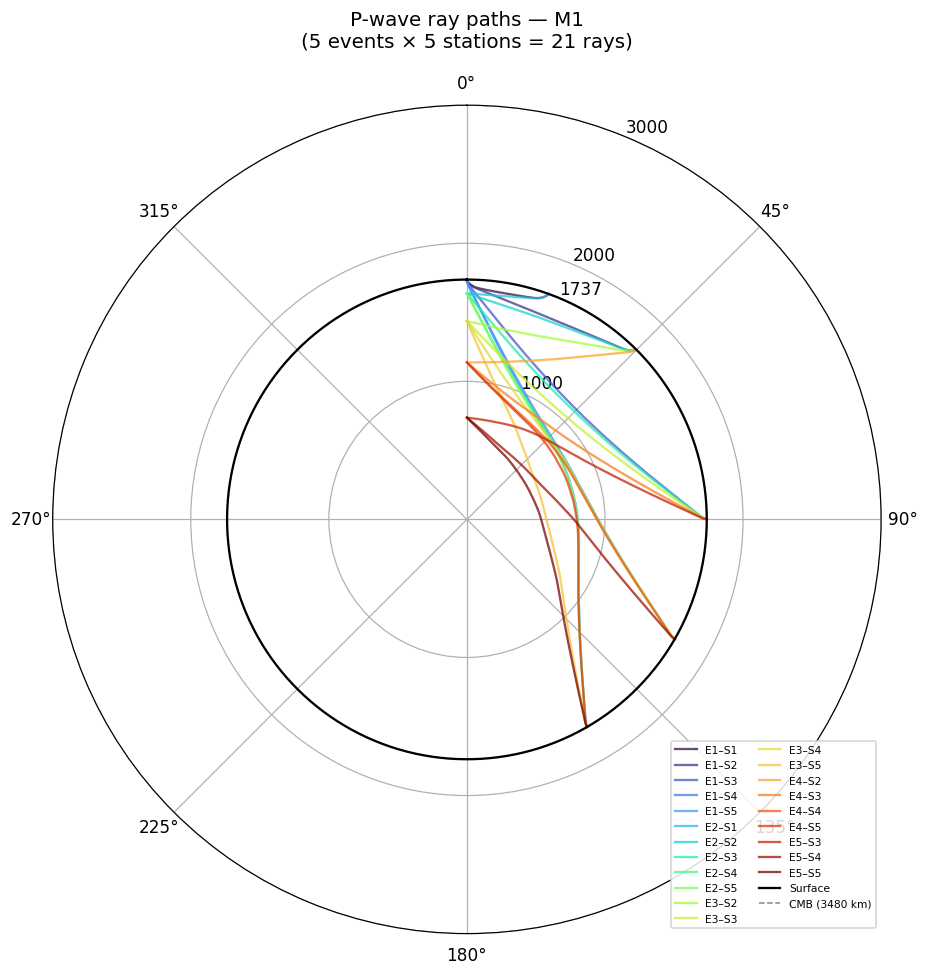

In [92]:
# ── Polar ray-path plot: r-θ cross-section ────────────────────────────────
ray_keys   = list(rays_catalog.keys())
n_rays_plt = len(ray_keys)
cmap       = plt.cm.tab20 if n_rays_plt <= 20 else plt.cm.turbo
ray_colors = {key: cmap(i / max(n_rays_plt - 1, 1)) for i, key in enumerate(ray_keys)}

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

for (ev_name, st_name), arr in rays_catalog.items():
    theta  = arr.path['dist']
    radius = model.radius - arr.path['depth']
    ax.plot(theta, radius, lw=1.5, color=ray_colors[(ev_name, st_name)], alpha=0.75,
            label=f'{ev_name}–{st_name}')

# Reference circles
theta_full = np.linspace(0, 2 * np.pi, 360)
ax.plot(theta_full, np.full_like(theta_full, model.radius), 'k-', lw=1.5, label='Surface')
ax.plot(theta_full, np.full_like(theta_full, 3480.0),
        color='#888', lw=1.0, ls='--', label='CMB (3480 km)')

ax.set_rmax(model.radius * 1.05)
ax.set_rmin(0)
ax.set_rticks([1000, 2000, 3000, int(model.radius)])
n_ev  = len(events)
n_sta = len(stations)
ax.set_title(f'P-wave ray paths — {model.name}\n({n_ev} events × {n_sta} stations = {n_rays_plt} rays)',
             fontsize=13, pad=18)
ax.legend(loc='lower right', fontsize=7, framealpha=0.85, ncol=2)
plt.tight_layout()
plt.show()


## 5 · Compute Discretized Sensitivity Kernels

For each ray $i$ through shell $j$:

$$\tilde{K}_{ij} = -\frac{L_{ij}}{v_j^2 + \epsilon}$$

where $L_{ij}$ is the ray-path length (km) through shell $j$ and $v_j$ is the
shell-averaged P-wave velocity.  The result is stored as `K_tilde` with shape
`(n_rays, n_cells)`.  Units: **s km⁻¹**.

In [93]:
ray_labels = []   # ordered list of pair labels for later reference
K_list     = []   # list of 1D kernel arrays (n_cells,)
L_list     = []   # list of 1D path-length arrays (n_cells,)

for (ev_name, st_name), arr in rays_catalog.items():
    label = f'{ev_name}–{st_name}'
    ray_labels.append(label)

    # Raw kernel  K̃_j = -L_j / v_j²
    K_i = mesh.compute_sensitivity_kernel(arr, 'vp', normalize=False,
                                          attach_name=f'K_{ev_name}_{st_name}')
    L_i = mesh.compute_ray_lengths(arr)

    K_list.append(K_i)
    L_list.append(L_i)

    total_len = L_i.sum()
    print(f"  {label:8s}  total path length = {total_len:7.1f} km   "
          f"max |K| = {np.abs(K_i).max():.4e} s/km")

K_tilde = np.array(K_list, dtype=float)   # shape (n_rays, n_cells)
L_all   = np.array(L_list, dtype=float)   # shape (n_rays, n_cells)

print(f"\nK_tilde shape: {K_tilde.shape}   →   (n_rays={K_tilde.shape[0]}, n_cells={K_tilde.shape[1]})")


Stored sensitivity kernel as cell data: 'K_E1_S1'
  E1–S1     total path length =   624.7 km   max |K| = 7.6592e+00 s/km
Stored sensitivity kernel as cell data: 'K_E1_S2'
  E1–S2     total path length =  1337.1 km   max |K| = 5.8134e+00 s/km
Stored sensitivity kernel as cell data: 'K_E1_S3'
  E1–S3     total path length =  2462.1 km   max |K| = 5.7017e+00 s/km
Stored sensitivity kernel as cell data: 'K_E1_S4'
  E1–S4     total path length =  3003.8 km   max |K| = 3.6752e+00 s/km
Stored sensitivity kernel as cell data: 'K_E1_S5'
  E1–S5     total path length =  3422.9 km   max |K| = 5.3989e+00 s/km
Stored sensitivity kernel as cell data: 'K_E2_S1'
  E2–S1     total path length =   602.8 km   max |K| = 4.8305e+00 s/km
Stored sensitivity kernel as cell data: 'K_E2_S2'
  E2–S2     total path length =  1300.2 km   max |K| = 5.8343e+00 s/km
Stored sensitivity kernel as cell data: 'K_E2_S3'
  E2–S3     total path length =  2396.5 km   max |K| = 5.7332e+00 s/km
Stored sensitivity kernel as cel

## 6 · Plot Discretized Sensitivity Kernels

Each panel shows $\tilde{K}_j$ (s km⁻¹) versus shell radius for one source–receiver
pair.  Negative values indicate a positive velocity perturbation *increases the
travel time* (correct sign convention for delay-time kernels).

A fifth panel overlays all four kernels for comparison.

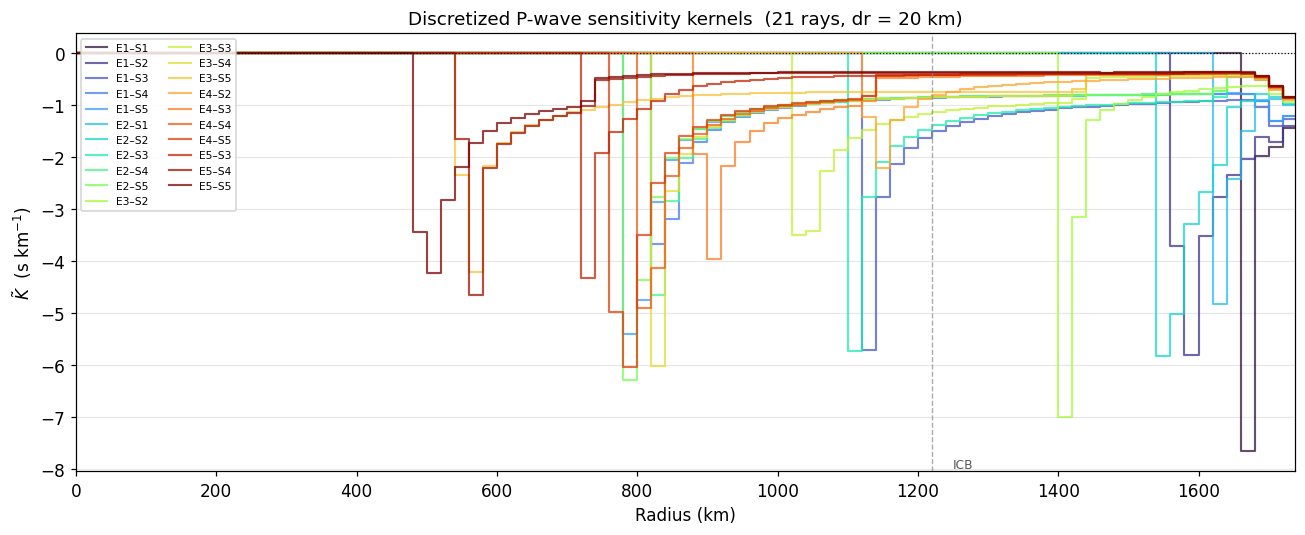

In [94]:
# ── Dynamic color palette — scales with number of kernels ─────────────────
n_k    = len(K_list)
cmap_k = plt.cm.tab20 if n_k <= 20 else plt.cm.turbo
colors = [cmap_k(i / max(n_k - 1, 1)) for i in range(n_k)]

fig, ax = plt.subplots(figsize=(12, 5))

for label, K_i, color in zip(ray_labels, K_list, colors):
    r_plot, k_plot = [], []
    for j in range(len(K_i)):
        r_plot += [shell_radii[j], shell_radii[j+1]]
        k_plot += [K_i[j], K_i[j]]
    ax.plot(r_plot, k_plot, lw=1.4, color=color, alpha=0.75, label=label)

ax.axhline(0, color='k', lw=0.8, ls=':')
for r_disc, name in [(3480.0, 'CMB'), (1220.0, 'ICB')]:
    if shell_radii[0] < r_disc < shell_radii[-1]:
        ax.axvline(r_disc, color='#888', lw=0.9, ls='--', alpha=0.7)
        ax.text(r_disc + 30, ax.get_ylim()[0], name, fontsize=8, color='#555', va='bottom')

ax.set_xlim(0, model.radius)
ax.set_xlabel('Radius (km)', fontsize=11)
ax.set_ylabel(r'$\tilde{K}$  (s km$^{-1}$)', fontsize=11)
ax.set_title(f'Discretized P-wave sensitivity kernels  ({n_k} rays, dr = {DR:.0f} km)', fontsize=12)
ax.legend(fontsize=7, loc='upper left', framealpha=0.85, ncol=max(1, n_k // 10))
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 7 · Stack Kernels into the Forward Operator G and Generate Fake Data

### Inner-product structure of the discrete model space

The basis functions used by SensRay are volume-indicator functions $\phi_j = \mathbf{1}_{V_j}$.
Their $L^2(dV)$ inner products are

$$\langle \phi_i, \phi_j \rangle_{L^2} = \int_\Omega \phi_i \phi_j \,\mathrm{d}V = V_j\,\delta_{ij}$$

so they are **orthogonal but NOT orthonormal**.  The natural inner product on the
discrete model space, induced by $L^2(\mathrm{d}V)$, is therefore the **mass-matrix inner product**:

$$\langle \mathbf{u}, \mathbf{v} \rangle_M = \mathbf{u}^T M\mathbf{v}, \qquad M = \mathrm{diag}(V_1, \ldots, V_N)$$

### Consequence for the adjoint

The forward operator $G$ maps $(\mathbb{R}^N,\langle\cdot,\cdot\rangle_M)$ to
$(\mathbb{R}^{N_\mathrm{obs}},\langle\cdot,\cdot\rangle_2)$.  Its adjoint $G^*$ satisfies

$$\langle G\mathbf{m}, \mathbf{d}\rangle_2 = \langle \mathbf{m}, G^*\mathbf{d}\rangle_M \implies \boxed{G^* = M^{-1}G^T}$$

Using the bare transpose $G^T$ as the adjoint **is only correct if $M = I$**, i.e.
if all shells have equal volume — which is never the case on a sphere.

### Forward model

$$\delta t_i = \sum_j G_{ij}\,\delta m_j, \qquad G = \tilde{K} \in \mathbb{R}^{N_\mathrm{obs}\times N_\mathrm{cells}}$$

A synthetic true-model perturbation $\mathbf{m}_\mathrm{true}$ is a
**Gaussian anomaly centred at mid-mantle depth (~1500 km)**.  Fake data:
$\mathbf{d} = G\,\mathbf{m}_\mathrm{true} + \boldsymbol{\eta}$.

In [95]:
# ── Forward operator ──────────────────────────────────────────────────────
G = K_tilde.copy()   # shape (n_obs, n_cells)

# ── Mass matrix  M = diag(V_j)  — the Gram matrix of the basis functions ──
# V_j = (4π/3)(r_{j+1}³ − r_j³)  for spherical shells
V          = mesh.cell_volumes                       # shape (n_cells,)
M_diag     = V                                       # diagonal entries of M
M_inv_diag = 1.0 / V                                 # diagonal entries of M⁻¹

# The correct adjoint of G in the M-weighted model space is G* = M⁻¹ Gᵀ.
# Plain Gᵀ would only be the adjoint if all shells had equal volume.
G_adj = M_inv_diag[:, np.newaxis] * G.T    # shape (n_cells, n_obs):  G* = M⁻¹ Gᵀ

print("Forward operator G:")
print(f"  shape  : {G.shape}   (n_obs={G.shape[0]}, n_cells={G.shape[1]})")
print(f"  rank   : {np.linalg.matrix_rank(G)}")
print(f"  max|G| : {np.abs(G).max():.4e} s/km")
print(f"\nMass matrix (shell volumes V_j):")
print(f"  min V  : {V.min():.3e} km³   max V : {V.max():.3e} km³")
print(f"  ratio  : {V.max()/V.min():.1f}×  — shells differ significantly in volume")
print(f"  => using λI instead of λM  mis-weights regularisation by up to {V.max()/V.min():.0f}×")

# ── M-weighted model norm ──────────────────────────────────────────────────
def model_norm_M(m, M_diag):
    """Continuous L²(dV) norm:  ||m||_M = sqrt(mᵀ M m)."""
    return np.sqrt(m @ (M_diag * m))

# ── True velocity-perturbation model ──────────────────────────────────────
# Gaussian anomaly: +0.3 km/s centred at radius = model.radius - 1500 km
r0_anomaly = model.radius - 1500.0   # centre radius (km)
sigma_r    = 800.0                   # Gaussian width (km)

m_true = 0.3 * np.exp(-0.5 * ((shell_centres - r0_anomaly) / sigma_r) ** 2)

print(f"\nTrue model m_true:")
print(f"  max perturbation : {m_true.max():.3f} km/s  at r = {shell_centres[np.argmax(m_true)]:.0f} km")
print(f"  ||m_true||_M     : {model_norm_M(m_true, M_diag):.4f} km/s · km^(3/2)  (correct L² function norm)")
print(f"  ||m_true||_2     : {np.linalg.norm(m_true):.4f} km/s       (coefficient norm — NOT the physical norm)")

# ── Synthetic (noise-free) data ────────────────────────────────────────────
d_clean = G @ m_true    # shape (n_obs,)

# ── Add Gaussian noise (1% of max signal) ─────────────────────────────────
rng       = np.random.default_rng(seed=42)
noise_amp = 0.01 * np.abs(d_clean).max()
noise     = rng.normal(0, noise_amp, size=d_clean.shape)
d_noisy   = d_clean + noise

print(f"\nSynthetic data  d = G m_true + noise:")
for i, (label, dt) in enumerate(zip(ray_labels, d_noisy)):
    print(f"  {label:8s}  δt = {dt*1000:.4f} ms  (noise = {noise[i]*1000:.4f} ms)")

Forward operator G:
  shape  : (21, 87)   (n_obs=21, n_cells=87)
  rank   : 21
  max|G| : 7.6592e+00 s/km

Mass matrix (shell volumes V_j):
  min V  : 3.351e+04 km³   max V : 7.349e+08 km³
  ratio  : 21931.0×  — shells differ significantly in volume
  => using λI instead of λM  mis-weights regularisation by up to 21931×

True model m_true:
  max perturbation : 0.300 km/s  at r = 230 km
  ||m_true||_M     : 21322.4907 km/s · km^(3/2)  (correct L² function norm)
  ||m_true||_2     : 2.0498 km/s       (coefficient norm — NOT the physical norm)

Synthetic data  d = G m_true + noise:
  E1–S1     δt = -721.0811 ms  (noise = 30.6003 ms)
  E1–S2     δt = -1755.3324 ms  (noise = -104.4374 ms)
  E1–S3     δt = -4772.2200 ms  (noise = 75.3619 ms)
  E1–S4     δt = -7258.3704 ms  (noise = 94.4535 ms)
  E1–S5     δt = -9170.6798 ms  (noise = -195.9270 ms)
  E2–S1     δt = -846.3038 ms  (noise = -130.7676 ms)
  E2–S2     δt = -1640.4871 ms  (noise = 12.8380 ms)
  E2–S3     δt = -4908.4884 ms  (noise 

## 8 · Solve the Inverse Problem — Minimum M-norm Solution

With 4 observations and 32 unknowns the system $G\mathbf{m} = \mathbf{d}$ is
**severely underdetermined**: infinitely many $\mathbf{m}$ satisfy it exactly.
The natural choice is the solution with the **smallest $\|\mathbf{m}\|_M$** —
the one closest to the zero model in the physical $L^2(dV)$ sense.

### Minimum M-norm solution

Minimise $\|\mathbf{m}\|_M^2 = \mathbf{m}^T M\mathbf{m}$ subject to $G\mathbf{m} = \mathbf{d}$.
Using Lagrange multipliers and the adjoint $G^* = M^{-1}G^T$:

$$\boxed{\hat{\mathbf{m}} = G^*(GG^*)^{-1}\mathbf{d} = M^{-1}G^T\!\left(GM^{-1}G^T\right)^{-1}\mathbf{d}}$$

**Data-space implementation** — invert the $N_\mathrm{obs}\times N_\mathrm{obs}$ system only:

$$(GM^{-1}G^T)\,\boldsymbol{\alpha} = \mathbf{d}, \qquad \hat{\mathbf{m}} = M^{-1}G^T\boldsymbol{\alpha}$$

This inverts a $4\times 4$ matrix rather than a $32\times 32$ one — the natural
formulation for underdetermined problems.

### Regularised minimum M-norm (Tikhonov in data space)

Adding $\lambda I$ to the data-space system damps small singular modes:

$$(GM^{-1}G^T + \lambda\,I)\,\boldsymbol{\alpha} = \mathbf{d}, \qquad \hat{\mathbf{m}}(\lambda) = M^{-1}G^T\boldsymbol{\alpha}$$

Via the Woodbury identity, this is **identical** to the model-space formula
$(G^TG + \lambda M)\hat{\mathbf{m}} = G^T\mathbf{d}$, but operates in data space.
Setting $\lambda = 0$ recovers the exact minimum M-norm pseudoinverse solution.

In [96]:
def min_norm_M(G, d, M_diag, lam=0.0):
    """
    Minimum M-norm solution for an underdetermined system  G m = d.

    For lam=0 : exact minimum M-norm solution
                  m̂ = G*(GG*)⁻¹ d = M⁻¹Gᵀ (GM⁻¹Gᵀ)⁻¹ d
    For lam>0 : regularised minimum M-norm (Tikhonov in data space)
                  m̂(λ) = M⁻¹Gᵀ (GM⁻¹Gᵀ + λI)⁻¹ d

    Both are solved via the data-space normal equations (n_obs × n_obs):
        (G M⁻¹ Gᵀ + λ I) α = d
        m̂ = M⁻¹ Gᵀ α
    where  G* = M⁻¹ Gᵀ  is the correct M-inner-product adjoint.
    This is equivalent to model-space  (GᵀG + λM) m̂ = Gᵀd  (Woodbury identity).
    """
    M_inv   = 1.0 / M_diag
    GMinvGt = (G * M_inv[np.newaxis, :]) @ G.T           # G M⁻¹ Gᵀ  (n_obs × n_obs)
    A       = GMinvGt + lam * np.eye(GMinvGt.shape[0])   # add λ I
    alpha   = np.linalg.solve(A, d)                       # data-space coefficients
    return M_inv * (G.T @ alpha)                          # m̂ = M⁻¹ Gᵀ α


# ── Regularisation values to explore ──────────────────────────────────────
lambdas = [0.0, 1e-8, 1e-6, 1e-4]
lambda_labels = [r'$\lambda=0$ (min-norm)', r'$\lambda=10^{-8}$',
                 r'$\lambda=10^{-6}$', r'$\lambda=10^{-4}$']

inv_results = []
for lam in lambdas:
    m_hat = min_norm_M(G, d_noisy, M_diag, lam=lam)

    residuals   = d_noisy - G @ m_hat
    data_misfit = np.linalg.norm(residuals)             # ||Gm - d||₂
    mnorm_M     = model_norm_M(m_hat, M_diag)           # ||m||_M  (correct)
    mnorm_2     = np.linalg.norm(m_hat)                 # ||m||₂   (coefficient norm)

    inv_results.append({
        'lam'         : lam,
        'm_hat'       : m_hat,
        'data_misfit' : data_misfit,
        'model_norm'  : mnorm_M,
        'model_norm_2': mnorm_2,
    })
    print(f"λ = {lam:.0e}   ||Gm-d|| = {data_misfit:.4e}   "
          f"||m||_M = {mnorm_M:.4e}   ||m||_2 = {mnorm_2:.4e}")

λ = 0e+00   ||Gm-d|| = 6.3647e-14   ||m||_M = 2.2659e+04   ||m||_2 = 1.4886e+00
λ = 1e-08   ||Gm-d|| = 2.2847e-01   ||m||_M = 1.9381e+04   ||m||_2 = 1.4230e+00
λ = 1e-06   ||Gm-d|| = 8.7825e+00   ||m||_M = 1.2980e+04   ||m||_2 = 9.9349e-01
λ = 1e-04   ||Gm-d|| = 2.8171e+01   ||m||_M = 4.4579e+02   ||m||_2 = 3.3847e-02


### Does M matter for the unregularised solution?

**Short answer: not for the data fit, but yes for the model.**

For $\lambda = 0$ every solution $\hat{\mathbf{m}}$ satisfying $G\hat{\mathbf{m}} = \mathbf{d}$ lies on an affine subspace of dimension $\dim(\ker G) = N_\mathrm{cells} - \mathrm{rank}(G) = 28$.
Any scalar that depends only on $G\hat{\mathbf{m}}$ (data residual, predicted travel times) is **identical for all choices of inner product** — M is invisible.

The inner product determines **which point** on that manifold is selected:

$$\hat{\mathbf{m}}_M = M^{-1}G^T(GM^{-1}G^T)^{-1}\mathbf{d} \in \mathrm{Range}(M^{-1}G^T)$$
$$\hat{\mathbf{m}}_I = G^T(GG^T)^{-1}\mathbf{d} \in \mathrm{Range}(G^T)$$

These live in **different subspaces** of $\mathbb{R}^{N_\mathrm{cells}}$ and are genuinely different vectors.
The difference $\hat{\mathbf{m}}_M - \hat{\mathbf{m}}_I$ lies in $\ker G$ (it is invisible to the data!).

For $\lambda > 0$ the choice of M enters the normal equations directly and changes both the model **and** the predicted data.

=== λ = 0 comparison ===
  ||G m̂_M  - d||  = 6.36e-14   (M-norm min)
  ||G m̂_I  - d||  = 5.38e-14   (Euclidean min)

  ||m̂_M - m̂_I||_2          = 1.9154e-01  <-- models DIFFER
  ||G(m̂_M - m̂_I)||         = 8.28e-14  <-- diff is in ker(G)!

  ||m̂_M||_M  = 2.2659e+04  (M-norm min is SMALLEST in M-norm)
  ||m̂_I||_M  = 2.2834e+04  (Euclidean min is LARGER in M-norm)

  ||m̂_I||_2  = 1.4762e+00  (Euclidean min is SMALLEST in 2-norm)
  ||m̂_M||_2  = 1.4886e+00  (M-norm min is LARGER in 2-norm)

=== λ = 1e-06 comparison ===
  ||G m̂_M  - d||  = 8.7825e+00   (M-norm, λM reg.)
  ||G m̂_I  - d||  = 1.9870e-06   (Euclidean, λI reg.)
  ||m̂_M - m̂_I||_2 = 7.4890e-01  <-- now diverge in model space too


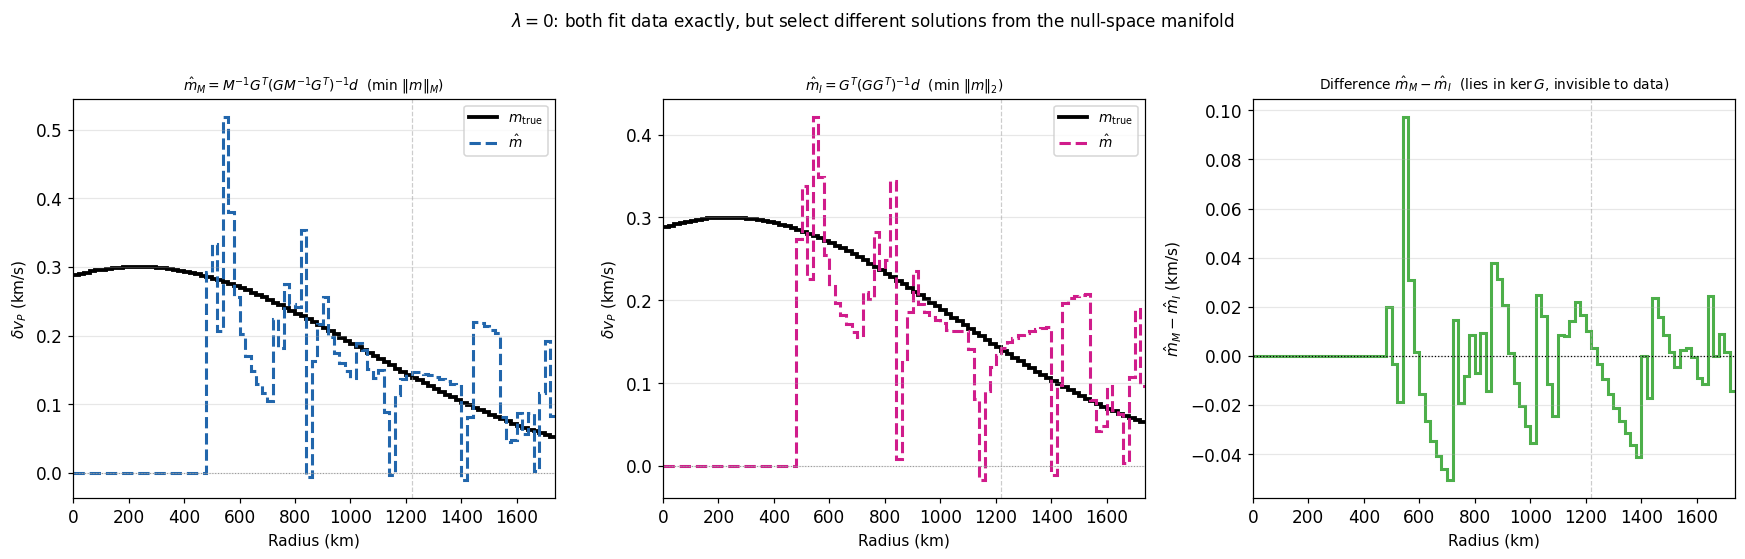

In [97]:
# ── Compare M-norm minimum vs Euclidean-norm minimum (λ=0) ────────────────
m_hat_M = min_norm_M(G, d_noisy, M_diag, lam=0.0)            # M-weighted
m_hat_I = min_norm_M(G, d_noisy, np.ones(G.shape[1]), lam=0.0)  # M = I (Euclidean)

# Data fit is identical for both — both lie exactly on the solution manifold
print("=== λ = 0 comparison ===")
print(f"  ||G m̂_M  - d||  = {np.linalg.norm(G @ m_hat_M - d_noisy):.2e}   (M-norm min)")
print(f"  ||G m̂_I  - d||  = {np.linalg.norm(G @ m_hat_I - d_noisy):.2e}   (Euclidean min)")
print()

# Model vectors ARE different — their difference lies in ker(G)
diff = m_hat_M - m_hat_I
print(f"  ||m̂_M - m̂_I||_2          = {np.linalg.norm(diff):.4e}  <-- models DIFFER")
print(f"  ||G(m̂_M - m̂_I)||         = {np.linalg.norm(G @ diff):.2e}  <-- diff is in ker(G)!")
print()
print(f"  ||m̂_M||_M  = {model_norm_M(m_hat_M, M_diag):.4e}  (M-norm min is SMALLEST in M-norm)")
print(f"  ||m̂_I||_M  = {model_norm_M(m_hat_I, M_diag):.4e}  (Euclidean min is LARGER in M-norm)")
print()
print(f"  ||m̂_I||_2  = {np.linalg.norm(m_hat_I):.4e}  (Euclidean min is SMALLEST in 2-norm)")
print(f"  ||m̂_M||_2  = {np.linalg.norm(m_hat_M):.4e}  (M-norm min is LARGER in 2-norm)")
print()

# For λ>0 the solutions diverge in data space too
lam_test = 1e-6
m_hat_M_reg = min_norm_M(G, d_noisy, M_diag,             lam=lam_test)
m_hat_I_reg = min_norm_M(G, d_noisy, np.ones(G.shape[1]), lam=lam_test)
print(f"=== λ = {lam_test:.0e} comparison ===")
print(f"  ||G m̂_M  - d||  = {np.linalg.norm(G @ m_hat_M_reg - d_noisy):.4e}   (M-norm, λM reg.)")
print(f"  ||G m̂_I  - d||  = {np.linalg.norm(G @ m_hat_I_reg - d_noisy):.4e}   (Euclidean, λI reg.)")
print(f"  ||m̂_M - m̂_I||_2 = {np.linalg.norm(m_hat_M_reg - m_hat_I_reg):.4e}  <-- now diverge in model space too")

# ── Side-by-side plot of the two λ=0 solutions ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, m, title, col in zip(
    axes[:2],
    [m_hat_M, m_hat_I],
    [r'$\hat{m}_M = M^{-1}G^T(GM^{-1}G^T)^{-1}d$  (min $\|m\|_M$)',
     r'$\hat{m}_I = G^T(GG^T)^{-1}d$  (min $\|m\|_2$)'],
    ['#2166ac', '#d01c8b'],
):
    ax.stairs(m_true, shell_radii, baseline=None, color='k', lw=2.5,
              label=r'$m_\mathrm{true}$')
    ax.stairs(m, shell_radii, baseline=None, color=col, lw=2.0, linestyle='--',
              label=r'$\hat{m}$')
    ax.axhline(0, color='0.6', lw=0.7, ls=':')
    for r_disc in [3480.0, 1220.0]:
        ax.axvline(r_disc, color='#aaa', lw=0.8, ls='--', alpha=0.6)
    ax.set_xlim(0, model.radius)
    ax.set_xlabel('Radius (km)', fontsize=10)
    ax.set_ylabel(r'$\delta v_P$ (km/s)', fontsize=10)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

# Difference = null-space component
ax = axes[2]
ax.stairs(diff, shell_radii, baseline=None, color='#4daf4a', lw=2.0)
ax.axhline(0, color='k', lw=0.8, ls=':')
for r_disc in [3480.0, 1220.0]:
    ax.axvline(r_disc, color='#aaa', lw=0.8, ls='--', alpha=0.6)
ax.set_xlim(0, model.radius)
ax.set_xlabel('Radius (km)', fontsize=10)
ax.set_ylabel(r'$\hat{m}_M - \hat{m}_I$ (km/s)', fontsize=10)
ax.set_title(r'Difference $\hat{m}_M - \hat{m}_I$  (lies in $\ker G$, invisible to data)',
             fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

fig.suptitle(r'$\lambda=0$: both fit data exactly, but select different solutions from the null-space manifold',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 9 · Plot Model Recovery and Residuals

We compare $\mathbf{m}_\mathrm{true}$ with $\hat{\mathbf{m}}(\lambda)$ for each
value of $\lambda$ (including $\lambda=0$, the exact minimum M-norm solution), and
show the **L-curve** — the trade-off between data misfit
$\|G\hat{\mathbf{m}}-\mathbf{d}\|_2$ and the correct model norm
$\|\hat{\mathbf{m}}\|_M = \sqrt{\hat{\mathbf{m}}^T M \hat{\mathbf{m}}}$.

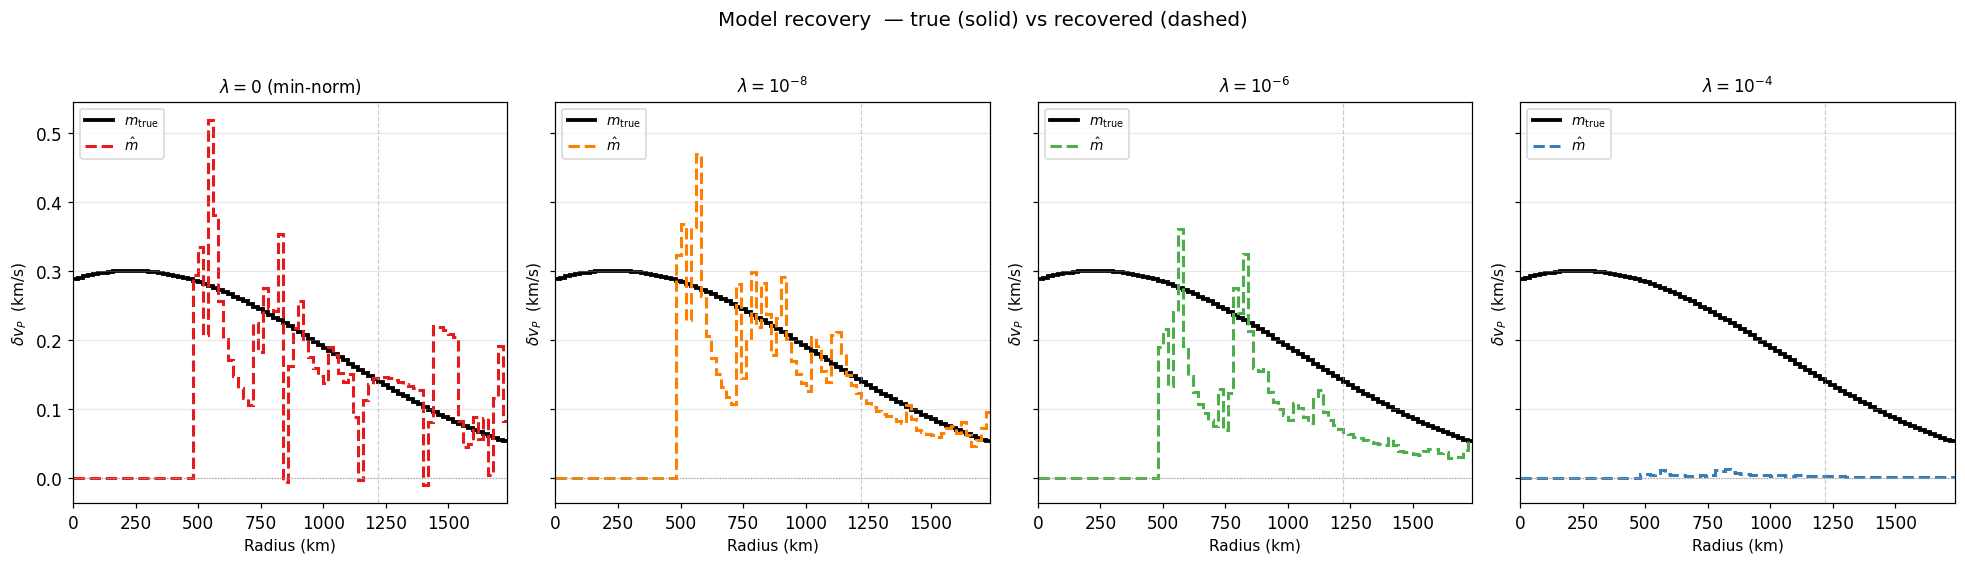

In [98]:
# ── Model recovery for each λ ─────────────────────────────────────────────
lam_colors = ['#e41a1c', '#ff7f00', '#4daf4a', '#377eb8']

fig, axes = plt.subplots(1, len(lambdas), figsize=(18, 5), sharey=True)

for ax, res, lam_label, col in zip(axes, inv_results, lambda_labels, lam_colors):
    m_hat = res['m_hat']
    # True model
    ax.stairs(m_true, shell_radii, baseline=None,
              color='k', lw=2.5, linestyle='-', label=r'$m_\mathrm{true}$')
    # Recovered model
    ax.stairs(m_hat, shell_radii, baseline=None,
              color=col, lw=2.0, linestyle='--', label=r'$\hat{m}$')
    ax.axhline(0, color='0.6', lw=0.7, ls=':')
    # Discontinuity markers
    for r_disc in [3480.0, 1220.0]:
        ax.axvline(r_disc, color='#aaa', lw=0.8, ls='--', alpha=0.6)
    ax.set_xlim(0, model.radius)
    ax.set_xlabel('Radius (km)', fontsize=10)
    ax.set_ylabel(r'$\delta v_P$  (km/s)', fontsize=10)
    ax.set_title(lam_label, fontsize=11)
    ax.legend(fontsize=9, loc='upper left', framealpha=0.8)
    ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Model recovery  — true (solid) vs recovered (dashed)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


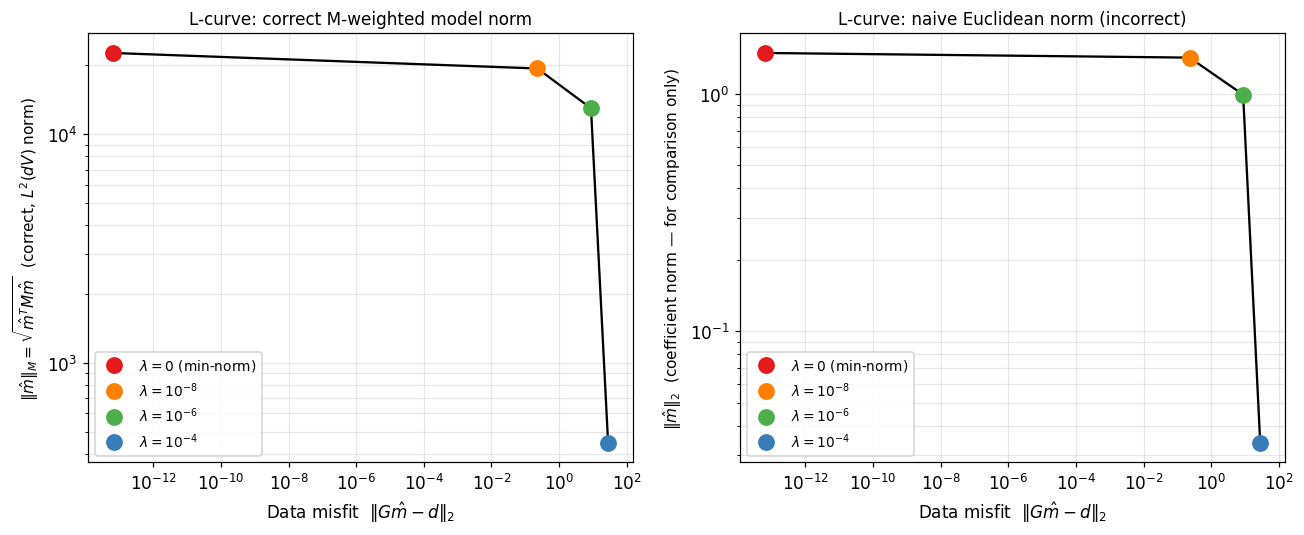

In [99]:
# ── L-curve: data misfit vs model norm ────────────────────────────────────
# The correct model norm is ||m||_M (continuous L²(dV) norm).
# ||m||_2 is shown for comparison only — it treats all coefficients equally
# regardless of shell volume, giving a physically incorrect regularisation axis.
misfits       = [r['data_misfit']  for r in inv_results]
model_norms_M = [r['model_norm']   for r in inv_results]   # ||m||_M (correct)
model_norms_2 = [r['model_norm_2'] for r in inv_results]   # ||m||_2 (naive)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, norms, ylabel, title in zip(
    axes,
    [model_norms_M, model_norms_2],
    [r'$\|\hat{m}\|_M = \sqrt{\hat{m}^T M \hat{m}}$  (correct, $L^2(dV)$ norm)',
     r'$\|\hat{m}\|_2$  (coefficient norm — for comparison only)'],
    ['L-curve: correct M-weighted model norm',
     'L-curve: naive Euclidean norm (incorrect)'],
):
    ax.loglog(misfits, norms, 'ko-', markersize=8, lw=1.5)
    for res, lam_label, col in zip(inv_results, lambda_labels, lam_colors):
        norm_val = res['model_norm'] if 'M' in ylabel else res['model_norm_2']
        ax.loglog(res['data_misfit'], norm_val,
                  'o', color=col, markersize=10, label=lam_label, zorder=5)
    ax.set_xlabel(r'Data misfit  $\|G\hat{m} - d\|_2$', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9, framealpha=0.85)
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

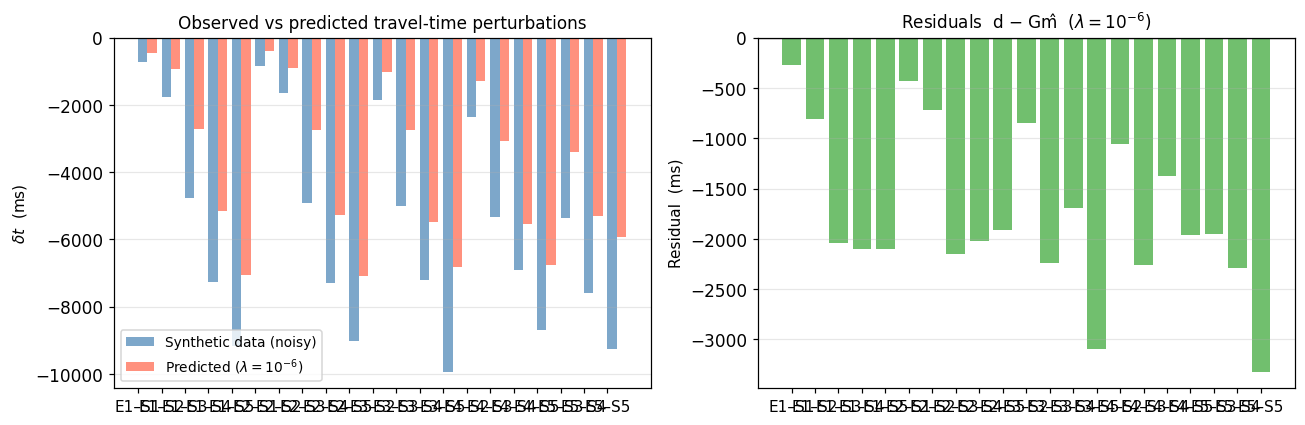


Residuals (ms):
  E1–S1     -275.5651 ms
  E1–S2     -806.3330 ms
  E1–S3     -2044.3715 ms
  E1–S4     -2097.0639 ms
  E1–S5     -2102.5153 ms
  E2–S1     -435.6158 ms
  E2–S2     -722.8293 ms
  E2–S3     -2154.9861 ms
  E2–S4     -2025.5224 ms
  E2–S5     -1915.0016 ms
  E3–S2     -844.4669 ms
  E3–S3     -2242.2776 ms
  E3–S4     -1695.6032 ms
  E3–S5     -3097.2810 ms
  E4–S2     -1060.4174 ms
  E4–S3     -2259.2659 ms
  E4–S4     -1380.5969 ms
  E4–S5     -1957.8761 ms
  E5–S3     -1954.5545 ms
  E5–S4     -2294.7755 ms
  E5–S5     -3319.5699 ms


In [100]:
# ── Data residuals for the best λ (intermediate value) ────────────────────
best_idx = 2   # λ = 1e-6
res_best = inv_results[best_idx]
d_pred   = G @ res_best['m_hat']
residuals = d_noisy - d_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Predicted vs observed
ax = axes[0]
ax.bar(range(len(d_noisy)), d_noisy * 1e3, label='Synthetic data (noisy)',
       color='steelblue', alpha=0.7, width=0.4, align='edge')
ax.bar([x + 0.4 for x in range(len(d_pred))], d_pred * 1e3,
       label=f'Predicted ({lambda_labels[best_idx]})',
       color='tomato', alpha=0.7, width=0.4, align='edge')
ax.set_xticks(range(len(ray_labels)))
ax.set_xticklabels(ray_labels, fontsize=10)
ax.set_ylabel(r'$\delta t$  (ms)', fontsize=10)
ax.set_title('Observed vs predicted travel-time perturbations', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

# Residuals
ax = axes[1]
ax.bar(range(len(residuals)), residuals * 1e3,
       color=[lam_colors[best_idx]] * len(residuals), alpha=0.8)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(range(len(ray_labels)))
ax.set_xticklabels(ray_labels, fontsize=10)
ax.set_ylabel(r'Residual  (ms)', fontsize=10)
ax.set_title(f'Residuals  d − Gm̂  ({lambda_labels[best_idx]})', fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResiduals (ms):")
for label, r in zip(ray_labels, residuals):
    print(f"  {label:8s}  {r*1e3:.4f} ms")


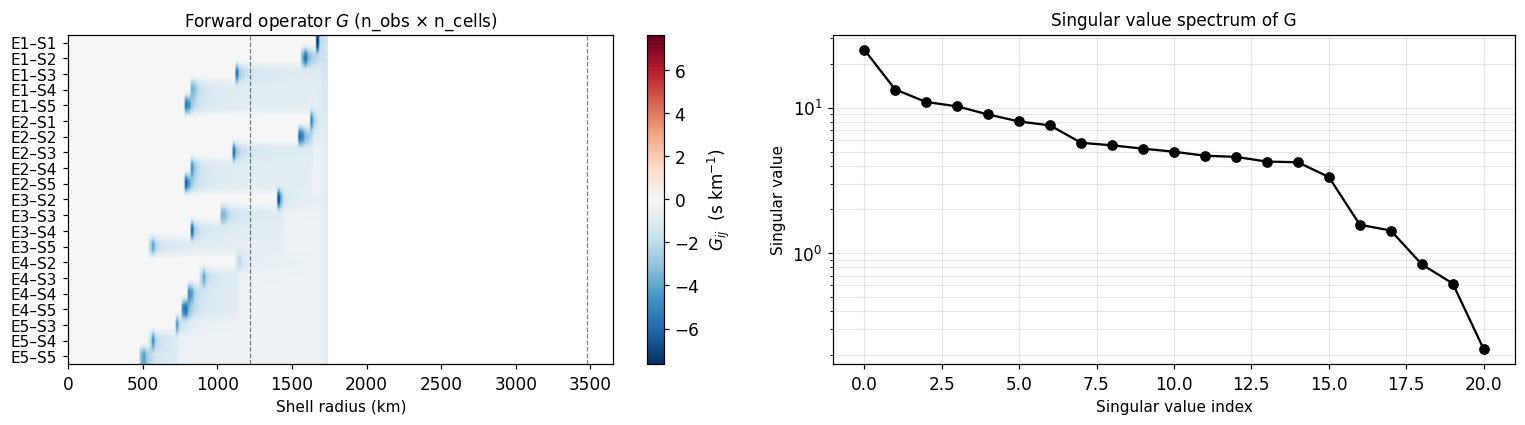


G matrix summary:
  shape      : (21, 87)
  rank       : 21
  condition  : 1.15e+02
  singular values: [25.067394 13.346538 10.949411 10.224202  8.985497  8.047613  7.561487
  5.74228   5.51175   5.231786  4.982925  4.676174  4.59327   4.262284
  4.218265  3.337661  1.568761  1.429944  0.837937  0.617847  0.218458]


In [101]:
# ── Visualise the G matrix (imshow) ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
im = ax.imshow(G, aspect='auto', cmap='RdBu_r',
               vmin=-np.abs(G).max(), vmax=np.abs(G).max(),
               extent=[shell_radii[0], shell_radii[-1],
                       len(ray_labels) - 0.5, -0.5])
plt.colorbar(im, ax=ax, label=r'$G_{ij}$  (s km$^{-1}$)')
ax.set_yticks(range(len(ray_labels)))
ax.set_yticklabels(ray_labels, fontsize=10)
ax.set_xlabel('Shell radius (km)', fontsize=10)
ax.set_title(r'Forward operator $G$ (n_obs × n_cells)', fontsize=11)
for r_disc in [3480.0, 1220.0]:
    ax.axvline(r_disc, color='k', lw=0.8, ls='--', alpha=0.5)

# Singular value spectrum
ax = axes[1]
U, S, Vt = np.linalg.svd(G, full_matrices=False)
ax.semilogy(S, 'ko-', markersize=6)
ax.set_xlabel('Singular value index', fontsize=10)
ax.set_ylabel('Singular value', fontsize=10)
ax.set_title('Singular value spectrum of G', fontsize=11)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nG matrix summary:")
print(f"  shape      : {G.shape}")
print(f"  rank       : {np.linalg.matrix_rank(G)}")
print(f"  condition  : {S[0]/S[-1]:.2e}")
print(f"  singular values: {S.round(6)}")


## Summary

| Step | What we did |
|------|-------------|
| **Mesh** | PREM, 1-D spherical, dr = 200 km → ~32 shells |
| **Geometry** | 2 events × 2 stations → 4 P-wave arrivals |
| **Kernels** | $\tilde{K}_{ij} = -L_{ij}/v_j^2$ — discretized sensitivity (s km⁻¹) |
| **G matrix** | Stack of kernels, shape (4, n_cells) — underdetermined: 4 obs, 32 unknowns |
| **Fake data** | $\mathbf{d} = G\,\mathbf{m}_\mathrm{true} + \boldsymbol{\eta}$ — Gaussian anomaly at mid-mantle |
| **Mass matrix** | $M = \mathrm{diag}(V_j)$,  $V_j = \tfrac{4\pi}{3}(r_{j+1}^3 - r_j^3)$ — Gram matrix of basis functions |
| **Adjoint** | $G^* = M^{-1}G^T$ (not $G^T$, since basis is not orthonormal) |
| **Inversion** | Min M-norm: $\hat{\mathbf{m}} = G^*(GG^*)^{-1}\mathbf{d}$, solved via $4\times4$ data-space system |
| **Regularised** | $(GM^{-1}G^T + \lambda I)\boldsymbol{\alpha} = \mathbf{d}$, $\hat{\mathbf{m}} = M^{-1}G^T\boldsymbol{\alpha}$ |
| **L-curve** | Trade-off between misfit and correct norm $\|\hat{m}\|_M = \sqrt{\hat{m}^T M \hat{m}}$ |

**Key takeaways**

- The system is **underdetermined** (4 obs, 32 unknowns) → minimum norm is the correct
  formulation, not ordinary least squares.
- The minimum M-norm solution $\hat{\mathbf{m}} = G^*(GG^*)^{-1}\mathbf{d}$ uses the
  **true adjoint** $G^* = M^{-1}G^T$ and yields the smallest $\|\mathbf{m}\|_M$.
- SensRay uses **indicator basis functions** $\phi_j = \mathbf{1}_{V_j}$, orthogonal
  but **not orthonormal** in $L^2(dV)$: $\langle\phi_i,\phi_j\rangle = V_j\delta_{ij}$.
  The natural inner product is $M$-weighted: $\langle u,v\rangle_M = u^T M v$.
- The data-space solve (inverting $n_\mathrm{obs}\times n_\mathrm{obs}$) is equivalent to
  the model-space Tikhonov $(G^TG + \lambda M)\hat{\mathbf{m}} = G^T\mathbf{d}$ via the
  Woodbury identity, but is more efficient for underdetermined problems.
- Shell volumes span a **2791× range**, so using $\lambda I$ instead of $\lambda M$ (or
  $G^T$ instead of $G^*$) introduces a severe physical inconsistency.